In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [4]:
cancer = load_breast_cancer()
X_reg = cancer.data
y_reg = cancer.target
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [5]:
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Algoritmos KNN, Naive Bayes e Regressão Logística 

In [6]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=42
)

print("Tamanho do treino:", X_train_reg.shape)
print("Tamanho do teste:", X_test_reg.shape)

Tamanho do treino: (398, 30)
Tamanho do teste: (171, 30)


In [7]:
modelLogisticRegression = make_pipeline(StandardScaler(), LogisticRegression())

models = {
    "Naive Bayes": GaussianNB(),
    "Regressão Logística": modelLogisticRegression
}
visinhos = range(1, 51)
for k in visinhos:
    models[f"KNN (k={k})"] = KNeighborsClassifier(n_neighbors=k)
print(f"Total de modelos: {len(models)}")

Total de modelos: 52


In [8]:
def print_result(name, teste, predito):
    acc = accuracy_score(teste, predito)
    precision = precision_score(teste, predito)
    recall = recall_score(teste, predito)
    f1 = f1_score(teste, predito)
    return {"acc": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "nome": name,
            "cm": confusion_matrix(teste, predito)
            }

In [9]:
dados_totais = []
for name, model in models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    dados = print_result(name, y_test_reg, y_pred)
    dados_totais.append(dados)
    print(f"{name}: Acc: {dados['acc']*100:.1f}% Precision: {dados['precision']*100:.1f}% Recall: {dados['recall']*100:.1f}% F1: {dados['f1']*100:.1f}%")

Naive Bayes: Acc: 94.2% Precision: 94.5% Recall: 96.3% F1: 95.4%
Regressão Logística: Acc: 98.2% Precision: 99.1% Recall: 98.1% F1: 98.6%
KNN (k=1): Acc: 93.6% Precision: 93.7% Recall: 96.3% F1: 95.0%
KNN (k=2): Acc: 93.0% Precision: 97.1% Recall: 91.7% F1: 94.3%
KNN (k=3): Acc: 94.2% Precision: 94.5% Recall: 96.3% F1: 95.4%
KNN (k=4): Acc: 94.7% Precision: 98.1% Recall: 93.5% F1: 95.7%
KNN (k=5): Acc: 95.9% Precision: 94.7% Recall: 99.1% F1: 96.8%
KNN (k=6): Acc: 95.9% Precision: 97.2% Recall: 96.3% F1: 96.7%
KNN (k=7): Acc: 96.5% Precision: 96.4% Recall: 98.1% F1: 97.2%
KNN (k=8): Acc: 96.5% Precision: 96.4% Recall: 98.1% F1: 97.2%
KNN (k=9): Acc: 97.1% Precision: 96.4% Recall: 99.1% F1: 97.7%
KNN (k=10): Acc: 98.2% Precision: 98.2% Recall: 99.1% F1: 98.6%
KNN (k=11): Acc: 97.7% Precision: 97.3% Recall: 99.1% F1: 98.2%
KNN (k=12): Acc: 97.7% Precision: 97.3% Recall: 99.1% F1: 98.2%
KNN (k=13): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=14): Acc: 96.5% Precision: 96.4%

In [10]:
dados_totais = sorted(dados_totais, key=lambda x: x["f1"], reverse=True)
for dados in dados_totais:
    print(f"{dados['nome']}: Acc: {dados['acc']*100:.1f}% Precision: {dados['precision']*100:.1f}% Recall: {dados['recall']*100:.1f}% F1: {dados['f1']*100:.1f}%")

KNN (k=10): Acc: 98.2% Precision: 98.2% Recall: 99.1% F1: 98.6%
Regressão Logística: Acc: 98.2% Precision: 99.1% Recall: 98.1% F1: 98.6%
KNN (k=11): Acc: 97.7% Precision: 97.3% Recall: 99.1% F1: 98.2%
KNN (k=12): Acc: 97.7% Precision: 97.3% Recall: 99.1% F1: 98.2%
KNN (k=9): Acc: 97.1% Precision: 96.4% Recall: 99.1% F1: 97.7%
KNN (k=13): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=15): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=16): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=17): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=18): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=20): Acc: 96.5% Precision: 95.5% Recall: 99.1% F1: 97.3%
KNN (k=7): Acc: 96.5% Precision: 96.4% Recall: 98.1% F1: 97.2%
KNN (k=8): Acc: 96.5% Precision: 96.4% Recall: 98.1% F1: 97.2%
KNN (k=14): Acc: 96.5% Precision: 96.4% Recall: 98.1% F1: 97.2%
KNN (k=5): Acc: 95.9% Precision: 94.7% Recall: 99.1% F1: 96.8%
KNN (k=19): Acc: 95.9% Precision: 9

In [17]:
def show_cm(cm, nome):
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusão - {nome}')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Negativo', 'Positivo'], rotation=45)
    plt.yticks(tick_marks, ['Negativo', 'Positivo'])
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    plt.tight_layout()


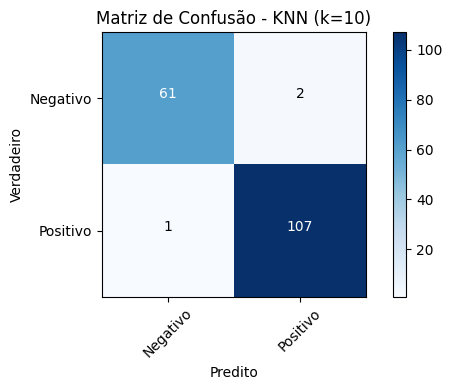

In [18]:
id = 0
show_cm(dados_totais[id]["cm"], dados_totais[id]["nome"])